# Olist E-commerce Exploratory Data Analysis
A reproducible, PostgreSQL-backed exploration of commercial performance, customers, products, delivery, and satisfaction. All primary analysis reads from the validated relational database rather than raw CSV files.

## 1. Business Problem
Understand the marketplace's revenue, customer retention, product mix, logistics performance, and review outcomes before selecting a machine-learning problem.

## 2. Database Connection
The reusable loader reads `DATABASE_URL` from the ignored project `.env`. SQLAlchemy connections are read-only for analytical extraction.

In [1]:
from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
from IPython.display import display, Image
from src.analysis.data_loader import load_analytical_datasets
from src.analysis.eda import prepare_features, quality_profile, generate_figures, calculate_metrics, write_reports

## 3. Data Extraction
Four analytical datasets are loaded at explicit grains: order, order item, review/order, and unique customer. Payments and freight are aggregated before joining to orders to prevent fan-out.

In [2]:
datasets = prepare_features(load_analytical_datasets())
{name: frame.shape for name, frame in datasets.items()}

{'orders': (99441, 22),
 'items': (112650, 9),
 'reviews': (99224, 7),
 'customers': (94990, 9),
 'quality': (1, 4)}

## 4. Data Understanding
Representative samples confirm column meaning without dumping full tables.

In [3]:
display(datasets['orders'].head(3))
display(datasets['items'].head(3))
display(datasets['reviews'].head(3))
display(datasets['customers'].head(3))

,order_id,customer_unique_id,order_status,purchase_timestamp,approved_at,delivered_carrier_at,delivered_customer_at,estimated_delivery_at,order_value,maximum_installments,...,customer_state,purchase_year,purchase_month,purchase_year_month,purchase_day_of_week,purchase_hour,delivery_days,estimated_delivery_days,delivery_delay_days,is_late_delivery
0,00018f77f2f0320c557190d7a144bdd3,eb28e67c4c0b83846050ddfb8a35d051,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,259.83,3.0,...,SP,2017,4,2017-04-01,Wednesday,10,16.216181,18.546458,-2.330278,False
1,000229ec398224ef6ca0657da4fc703e,3818d81c6709e39d06b2738a8d3a2474,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,216.87,5.0,...,MG,2018,1,2018-01-01,Sunday,14,7.948437,21.393391,-13.444954,False
2,000576fe39319847cbb9d288c5617fa6,fda4476abb6307ab3c415b7e6d026526,delivered,2018-07-04 12:08:27,2018-07-05 16:35:48,2018-07-05 12:15:00,2018-07-09 14:04:07,2018-07-25,880.75,10.0,...,SP,2018,7,2018-07-01,Wednesday,12,5.080324,20.494132,-15.413808,False


,order_id,order_item_id,product_id,seller_id,price,freight_value,product_category_name,category_english,order_status
0,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,239.9,19.93,pet_shop,pet_shop,delivered
1,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,199.0,17.87,moveis_decoracao,furniture_decor,delivered
2,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,199.9,18.14,ferramentas_jardim,garden_tools,delivered


,review_id,order_id,review_score,review_creation_date,review_answer_timestamp,delivery_status,delivery_delay_days
0,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,2018-03-10,2018-03-11 03:05:13,on_time_or_early,-4.029630
1,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,2018-02-17,2018-02-18 14:36:24,on_time_or_early,-20.271667
2,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,2018-03-01,2018-03-02 10:26:53,on_time_or_early,-8.310012


,customer_unique_id,first_purchase,last_purchase,order_count,total_spend,customer_state,customer_city,customer_order_count,is_repeat_customer
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,2018-05-10 10:56:27,1,141.90,SP,cajamar,1,False
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,2018-05-07 11:11:27,1,27.19,SP,osasco,1,False
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,2017-03-10 21:05:03,1,86.22,SC,sao jose,1,False


## 5. Data Quality
Dimensions, duplicate rows and business keys, missing cells, and categorical cardinality are quantified. Anomalies are documented rather than silently removed.

In [4]:
profile = quality_profile(datasets)
display(profile)
display(datasets['quality'])
display(datasets['orders'][['order_value','freight_value','delivery_days','delivery_delay_days']].describe(percentiles=[.01,.5,.95,.99]).T)

,dataset,rows,columns,duplicate_rows,duplicate_business_keys,missing_cells,categorical_cardinality
0,orders,99441,22,0,0,13805,199700
1,items,112650,9,0,0,1603,134866
2,reviews,99224,7,0,0,5742,197085
3,customers,94990,9,0,0,0,99125


,products_missing_category,zero_installment_payments,undefined_payment_methods,delivered_missing_timestamp
0,610,2,3,8


,count,mean,std,min,1%,50%,95%,99%,max
order_value,99440.0,160.990267,221.951257,0.000000,22.380000,105.290000,452.987500,1075.794900,13664.080000
freight_value,99441.0,22.645685,21.659564,0.000000,0.000000,17.090000,54.800000,104.730000,1794.960000
delivery_days,96476.0,12.558702,9.546530,0.533414,1.825203,10.217755,29.276016,46.049913,209.628611
delivery_delay_days,96476.0,-11.179120,10.186113,-146.016123,-35.154239,-11.948941,3.818458,18.939306,188.975081


## 6. Feature Creation
Derived variables include calendar components, actual and estimated delivery durations, delivery delay, late-delivery status, customer order count, and repeat-customer status. These variables describe observed outcomes; future modeling must exclude post-outcome columns when predicting before delivery.

In [5]:
datasets['orders'][['purchase_year','purchase_month','purchase_year_month','purchase_day_of_week','purchase_hour','delivery_days','estimated_delivery_days','delivery_delay_days','is_late_delivery']].head()

,purchase_year,purchase_month,purchase_year_month,purchase_day_of_week,purchase_hour,delivery_days,estimated_delivery_days,delivery_delay_days,is_late_delivery
0,2017,4,2017-04-01,Wednesday,10,16.216181,18.546458,-2.330278,False
1,2018,1,2018-01-01,Sunday,14,7.948437,21.393391,-13.444954,False
2,2018,7,2018-07-01,Wednesday,12,5.080324,20.494132,-15.413808,False
3,2018,7,2018-07-01,Monday,13,2.145046,20.416910,-18.271863,False
4,2018,3,2018-03-01,Saturday,22,4.075104,15.072106,-10.997002,False


## 7. Business Overview
Monthly performance and order-value distributions establish scale and seasonality. Months with fewer than 100 eligible orders are treated as partial boundary periods.

## 8. Customer Analysis
Customer spend, state distribution, and one-time versus repeat behavior highlight retention and geographic concentration.

## 9. Product Analysis
Category results use item price as gross merchandise value. Payment revenue is not joined directly to items, preventing duplication in multi-item orders.

## 10. Delivery Analysis
Actual duration, delay, and late rates are compared overall and across customer states.

## 11. Customer Satisfaction Analysis
Review distributions are compared with observed delivery performance without claiming causation.

## 12. Relationship Analysis
Pearson captures linear association while Spearman captures monotonic association. Sample sizes accompany delivery-delay/review and freight/duration comparisons.

INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


,metric,value
0,eligible_orders,98207
1,unique_customers,94990
2,revenue,15739137.01
3,average_order_value,160.266552
4,repeat_customer_rate_pct,3.04032
5,strongest_complete_month,2017-11
6,strongest_month_revenue,1172639.23
7,strongest_month_orders,7423
8,average_delivery_days,12.558217
9,late_delivery_rate_pct,8.112367


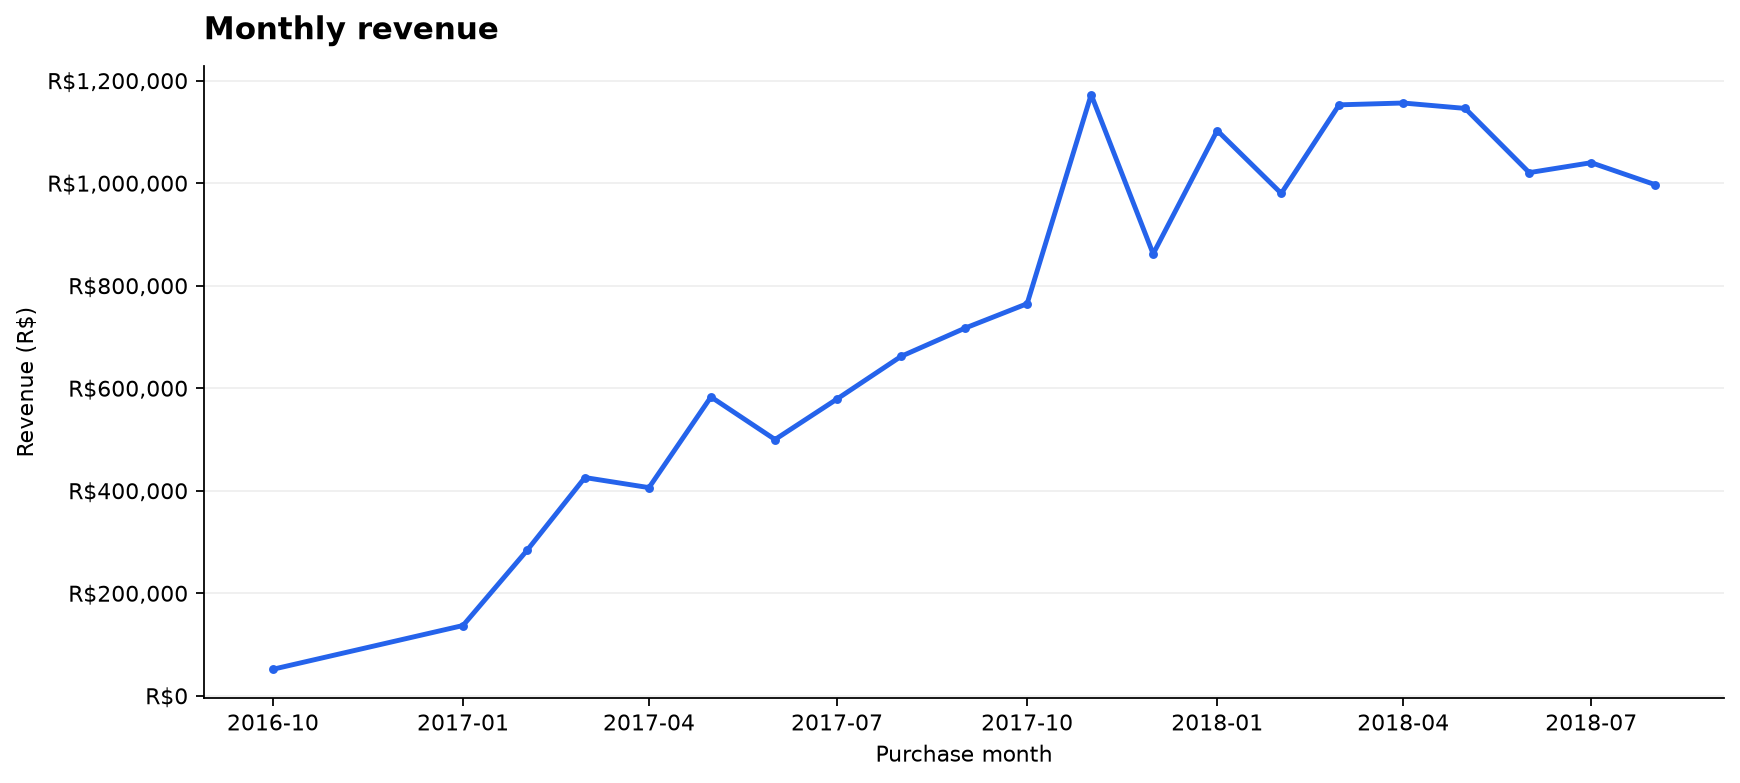

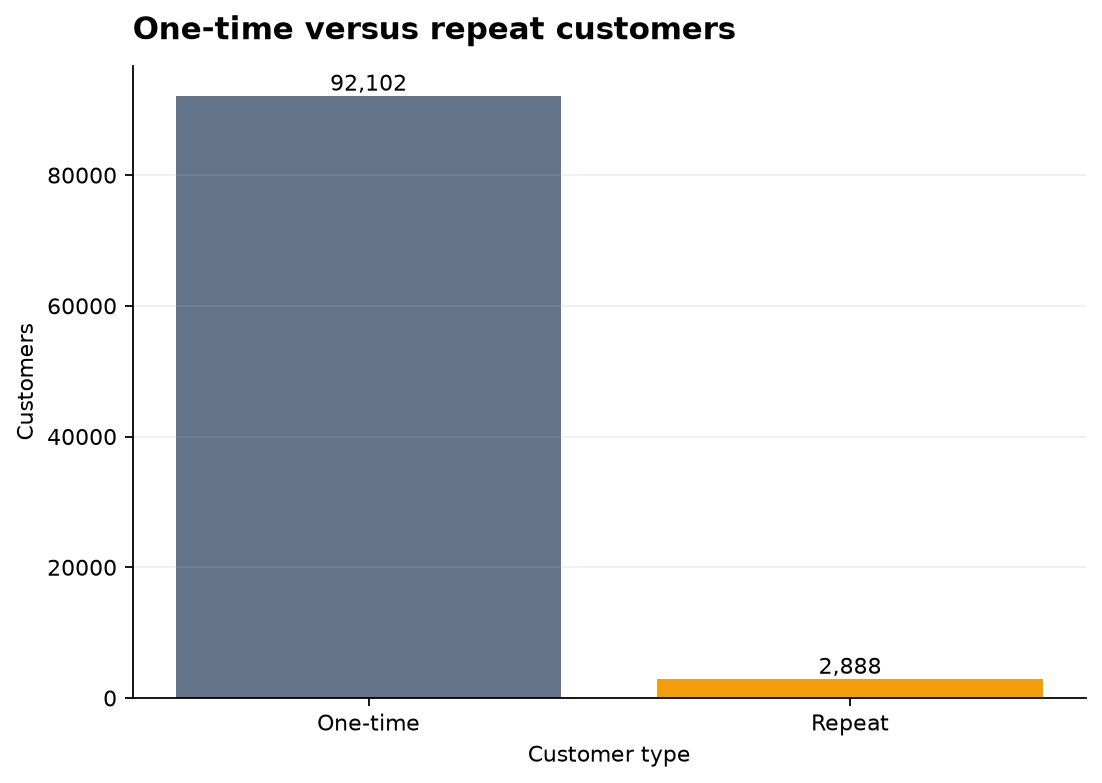

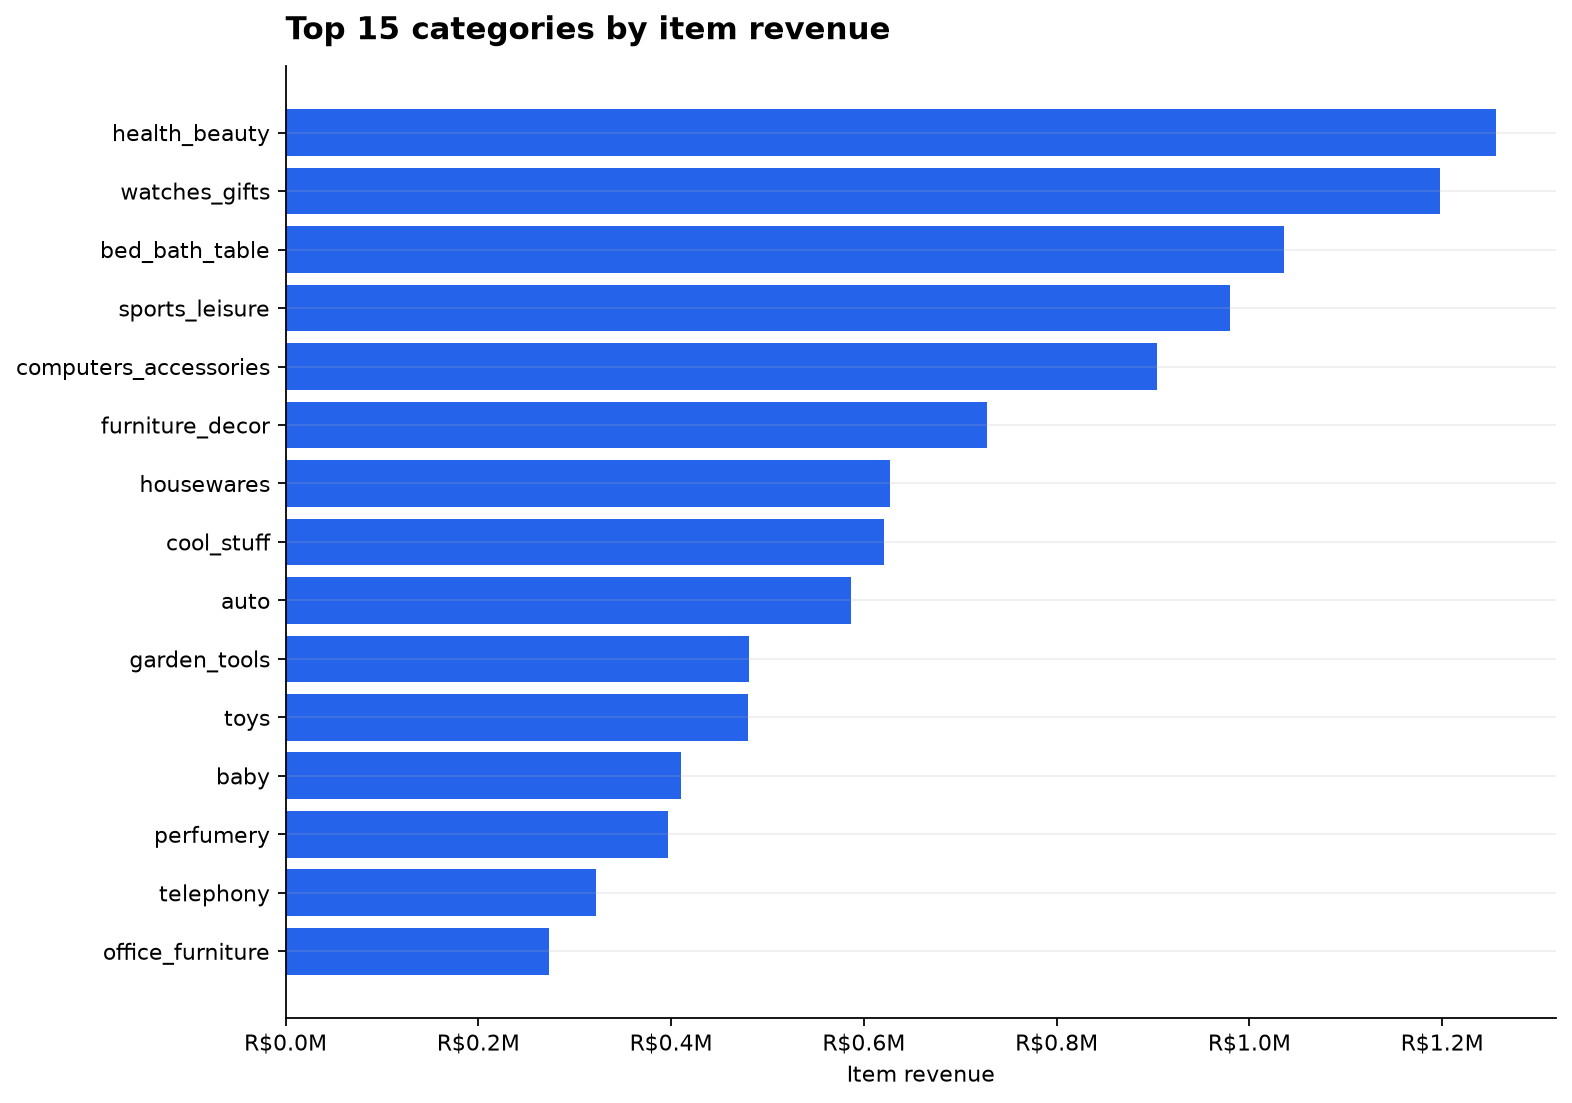

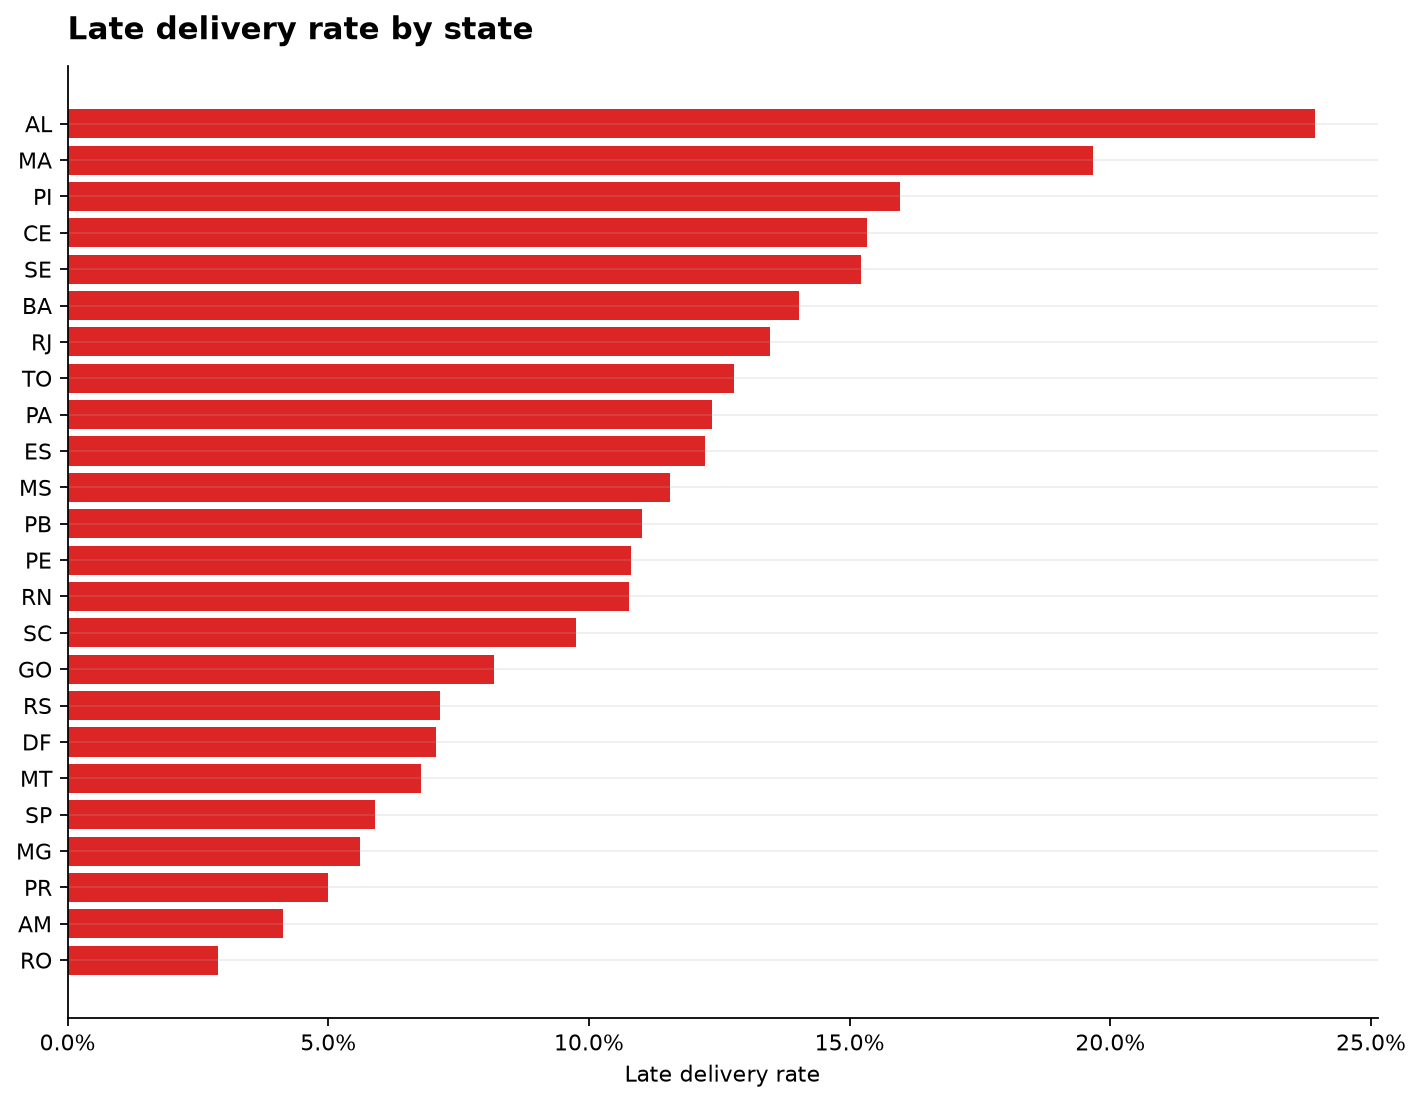

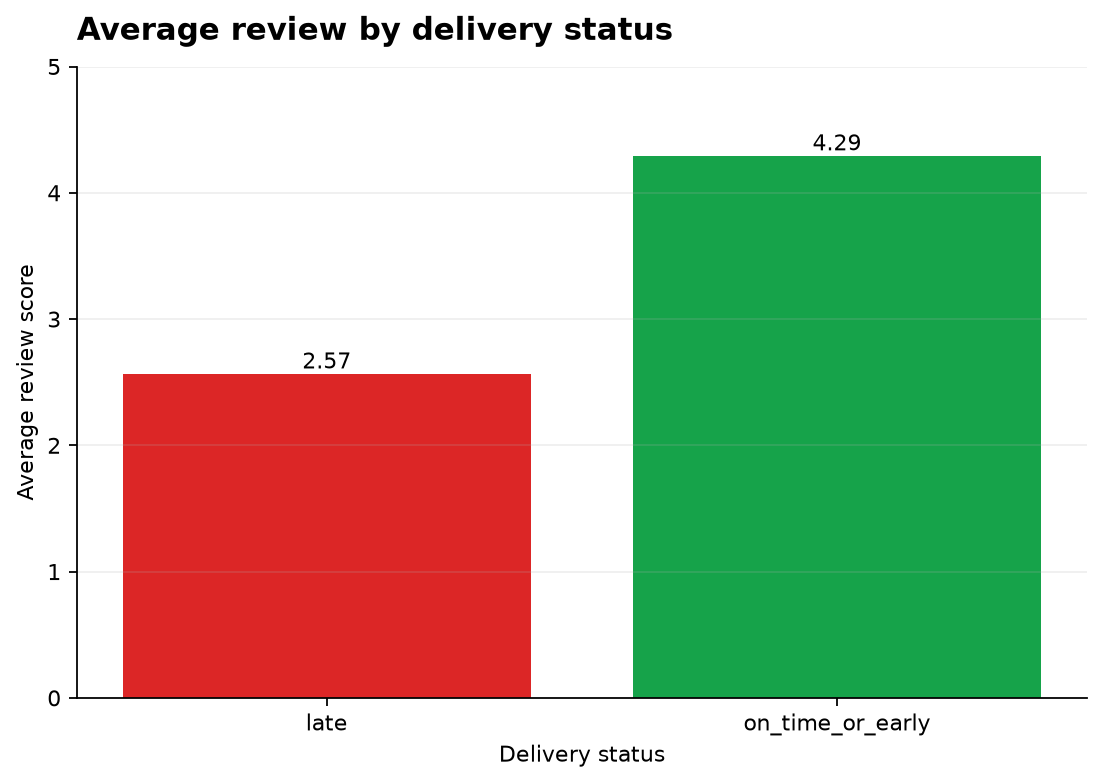

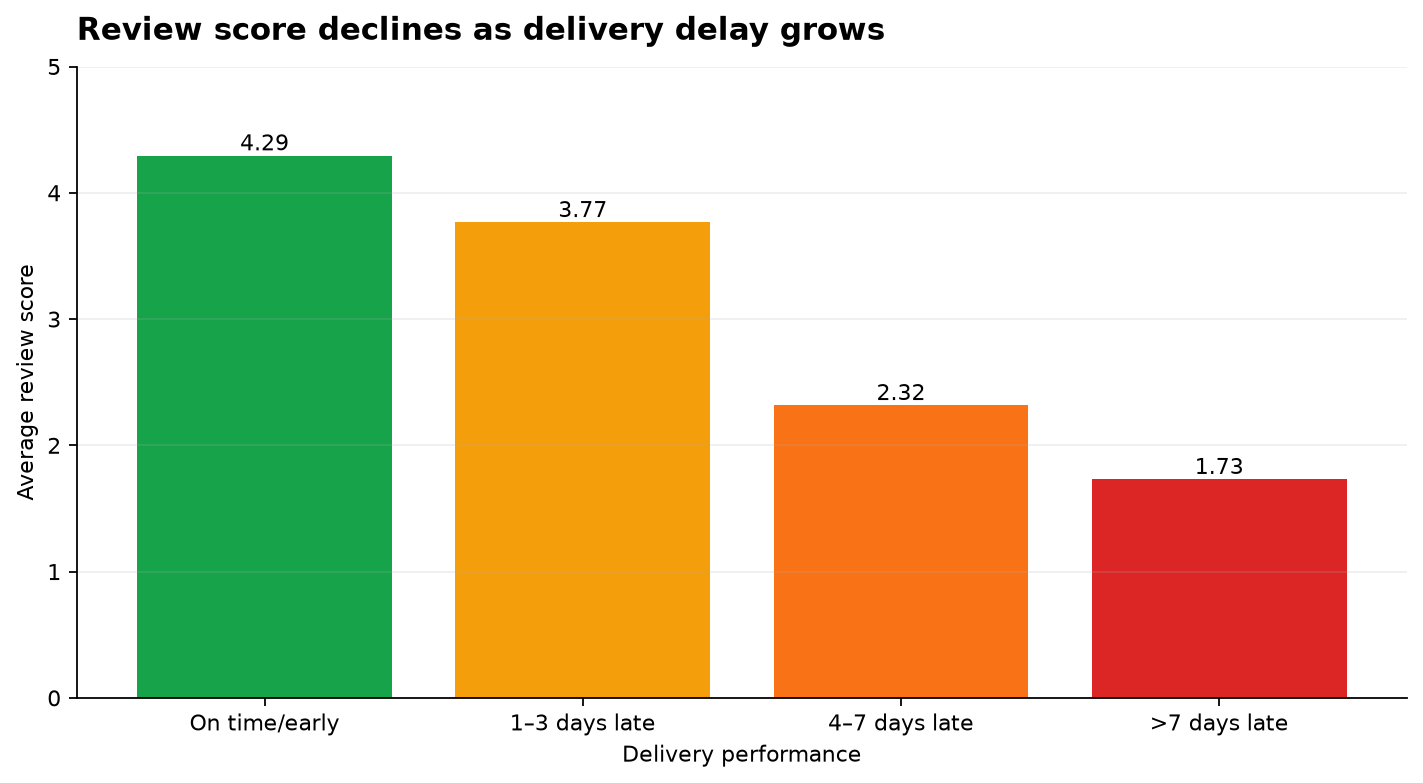

In [6]:
figures = generate_figures(datasets)
metrics, values = calculate_metrics(datasets)
write_reports(datasets, metrics, values, figures)
display(metrics)
for filename in ['monthly_revenue.png','repeat_customer_distribution.png','top_categories_revenue.png','late_delivery_by_state.png','review_by_delivery_status.png','delay_vs_review.png']:
    display(Image(filename=str(PROJECT_ROOT / 'reports' / 'figures' / filename), width=850))

## 13. Key Findings
The calculated findings are written to `reports/eda_summary.md`; this keeps notebook narrative and machine-generated metrics reconciled.

In [7]:
print((PROJECT_ROOT / 'reports' / 'eda_summary.md').read_text(encoding='utf-8'))

# Olist Exploratory Data Analysis Summary

## Executive summary

The PostgreSQL-backed EDA covers 98,207 eligible orders and 94,990 unique customers. Eligible payment revenue is R$15,739,137.01; canceled and unavailable orders are excluded from commercial metrics.

## Dataset overview

| Dataset | Rows | Columns | Duplicate business keys | Missing cells |
|---|---:|---:|---:|---:|
| orders | 99,441 | 22 | 0 | 13,805 |
| items | 112,650 | 9 | 0 | 1,603 |
| reviews | 99,224 | 7 | 0 | 5,742 |
| customers | 94,990 | 9 | 0 | 0 |

## Data-quality findings

- 610 products lack a category.
- 2 payment records report zero installments and 3 use an undefined payment method.
- 8 delivered orders lack an actual delivery timestamp.
- Negative item prices: 0; negative freight values: 0; negative actual delivery durations: 0.
- Purchases range from 2016-09-04 21:15:19 to 2018-09-03 09:06:57; sparse boundary months are excluded from strongest-month comparisons.
- Outliers are retained; distribution pl

## 14. Modeling Opportunities
The strongest next candidate is late-delivery prediction at order grain using only information available before dispatch. Other candidates are repeat-purchase prediction with temporal customer snapshots, review-score prediction, RFM segmentation, and time-series sales forecasting. Leakage controls and limitations are detailed in the generated summary. No model is trained in this step.